<a href="https://colab.research.google.com/github/ishaannandoskar-05/Deep-Learning/blob/main/exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = Sequential()
model.add(Dense(8,activation='relu',input_dim=(X_train.shape[1])))
model.add(Dense(4,activation='relu'))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [17]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4769 - loss: 0.6967 - val_accuracy: 0.6316 - val_loss: 0.6623
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7956 - loss: 0.6468 - val_accuracy: 0.8860 - val_loss: 0.6190
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8923 - loss: 0.6049 - val_accuracy: 0.9386 - val_loss: 0.5684
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8989 - loss: 0.5561 - val_accuracy: 0.9474 - val_loss: 0.5175
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9099 - loss: 0.5136 - val_accuracy: 0.9561 - val_loss: 0.4792
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9275 - loss: 0.4815 - val_accuracy: 0.9649 - val_loss: 0.4554
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9385 - loss: 0.4576 - val_accuracy: 0.9474 - val_loss: 0.4366
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9538 - loss: 0.4372 - val_accuracy: 0.9474 - val_loss

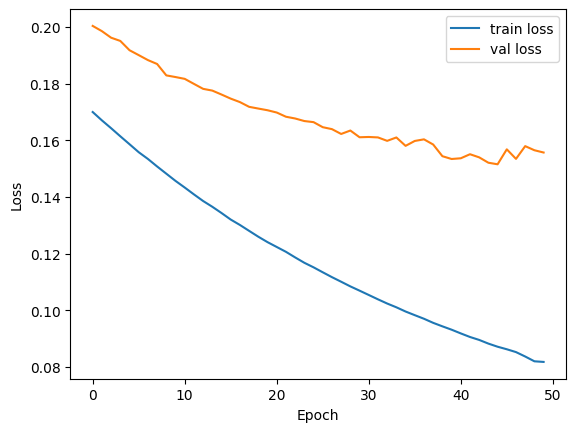

In [19]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

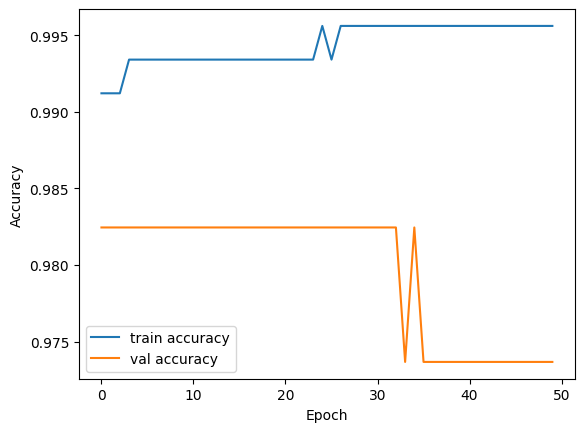

In [20]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9737 - loss: 0.1557
Test Loss: 0.15570081770420074, Test Accuracy: 0.9736841917037964


In [23]:
!pip install tensorflow

In [25]:
import tensorflow as tf

y_train_reshaped = tf.reshape(y_train, (-1, 1))

with tf.GradientTape() as tape:
    predictions = model(X_train, training=True)
    loss_value = tf.keras.losses.binary_crossentropy(y_train_reshaped, predictions)

gradients = tape.gradient(loss_value, model.trainable_variables)

for var, grad in zip(model.trainable_variables, gradients):
    print(var.name, grad.shape)

kernel (30, 8)
bias (8,)
kernel (8, 4)
bias (4,)
kernel (4, 2)
bias (2,)
kernel (2, 1)
bias (1,)
